# Laboratorio 5

- Pedro Pablo Guzmán Mayen

In [50]:
import pandas as pd
from scapy.all import *
import numpy as np
import matplotlib.pyplot as plt
import binascii
import matplotlib.dates as mdates
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score

## Parte 1

### Testeo de scapy

Primero, vamos a indicar que queremos capturar 10 paquetes

In [2]:
p = sniff(filter='ip', count=10)

In [3]:
for pkt in p:

    if IP in pkt:
        
        src_ip = pkt[IP].src
        dst_ip = pkt[IP].dst

        src_port = None
        dst_port = None

        if TCP in pkt:
            src_port = pkt[TCP].sport
            dst_port = pkt[TCP].dport
        elif UDP in pkt:
            src_port = pkt[UDP].sport
            dst_port = pkt[UDP].dport

        print(f'{src_ip} -> {dst_ip} | {src_port} -> {dst_port}')

192.168.0.4 -> 192.168.0.13 | 8009 -> 61572
192.168.0.4 -> 192.168.0.13 | 8009 -> 61572
192.168.0.13 -> 192.168.0.4 | 61572 -> 8009
192.168.0.13 -> 192.168.0.4 | 61572 -> 8009
192.168.0.13 -> 192.168.0.4 | 55973 -> 8009
192.168.0.4 -> 192.168.0.13 | 8009 -> 61572
192.168.0.4 -> 192.168.0.13 | 8009 -> 55973
192.168.0.13 -> 192.168.0.4 | 55973 -> 8009
192.168.0.13 -> 192.168.0.4 | 55973 -> 8009
192.168.0.4 -> 192.168.0.13 | 8009 -> 55973


### Detección de z-score

Ahora, vamos a cargar un archivo de tráfico de red más complejo y vamos a analizar mediante el z-score si hay anomalías. Primero convertimos en un df con la información relevante

In [4]:
packets = rdpcap('../resources/analisis_paquetes.pcap')
# Collect field names from IP/TCP/UDP (These will be columns in DF)
ip_fields = [field.name for field in IP().fields_desc]
tcp_fields = [field.name for field in TCP().fields_desc]
udp_fields = [field.name for field in UDP().fields_desc]

dataframe_fields = ip_fields + ['time'] + tcp_fields + ['payload','payload_raw','payload_hex']

# Create blank DataFrame
df = pd.DataFrame(columns=dataframe_fields)
for packet in packets[IP]:
    # Field array for each row of DataFrame
    field_values = []
    # Add all IP fields to dataframe
    for field in ip_fields:
        if field == 'options':
            # Retrieving number of options defined in IP Header
            field_values.append(len(packet[IP].fields[field]))
        else:
            field_values.append(packet[IP].fields[field])
    
    field_values.append(packet.time)
    
    layer_type = type(packet[IP].payload)
    for field in tcp_fields:
        try:
            if field == 'options':
                field_values.append(len(packet[layer_type].fields[field]))
            else:
                field_values.append(packet[layer_type].fields[field])
        except:
            field_values.append(None)
    
    # Append payload
    field_values.append(len(packet[layer_type].payload))
    field_values.append(packet[layer_type].payload.original)
    field_values.append(binascii.hexlify(packet[layer_type].payload.original))
    # Add row to DF
    df_append = pd.DataFrame([field_values], columns=dataframe_fields)
    df = pd.concat([df, df_append], axis=0)

# Reset Index
df = df.reset_index()
# Drop old index column
df = df.drop(columns="index")

Ahora que ya es un dataframe, vamos a analizar información relevante

In [47]:
df.shape

(62, 30)

In [5]:
df.head()

,version,ihl,tos,len,id,flags,frag,ttl,proto,chksum,...,dataofs,reserved,flags,window,chksum,urgptr,options,payload,payload_raw,payload_hex
0,4,5,0,961,1,,0,64,17,21222,...,None,None,None,None,62990,None,None,933,b'\x00\x0c\x01\x00\x00\x01\x00\x00\x00\x00\x00...,b'000c0100000100000000000006676f6f676c6503636f...
1,4,5,32,84,58919,,0,122,17,13836,...,None,None,None,None,65061,None,None,56,b'\x00\x0c\x81\x80\x00\x01\x00\x01\x00\x00\x00...,b'000c8180000100010000000006676f6f676c6503636f...
2,4,5,0,975,1,,0,64,17,21208,...,None,None,None,None,36378,None,None,947,b'\x00\x0c\x01\x00\x00\x01\x00\x00\x00\x00\x00...,b'000c0100000100000000000006676f6f676c6503636f...
3,4,5,32,84,59493,,0,122,17,13262,...,None,None,None,None,65063,None,None,56,b'\x00\x0c\x81\x80\x00\x01\x00\x01\x00\x00\x00...,b'000c8180000100010000000006676f6f676c6503636f...
4,4,5,0,1012,1,,0,64,17,21171,...,None,None,None,None,63846,None,None,984,b'\x00\x0c\x01\x00\x00\x01\x00\x00\x00\x00\x00...,b'000c0100000100000000000006676f6f676c6503636f...


In [6]:
df.columns

Index(['version', 'ihl', 'tos', 'len', 'id', 'flags', 'frag', 'ttl', 'proto',
       'chksum', 'src', 'dst', 'options', 'time', 'sport', 'dport', 'seq',
       'ack', 'dataofs', 'reserved', 'flags', 'window', 'chksum', 'urgptr',
       'options', 'payload', 'payload_raw', 'payload_hex'],
      dtype='str')

1. Muestre cuál es la IP origen más frecuente

In [7]:
df['src'].value_counts()

src
10.1.10.53     31
84.54.22.33    29
75.75.75.75     2
Name: count, dtype: int64

La ip de origen más frecuente es la 10.1.10.53

2. Muestre cuál es la IP destino más frecuente

In [8]:
df['dst'].value_counts()

dst
10.1.10.53     31
84.54.22.33    29
75.75.75.75     2
Name: count, dtype: int64

La ip de destino más frecuente es 10.1.10.53, la misma que el inciso anterior

3. ¿A qué IPs se comunica la IP del inciso a?

In [9]:
df_frequent_src_ip = df[df['src'] == '10.1.10.53']

df_frequent_src_ip['dst'].value_counts()

dst
84.54.22.33    29
75.75.75.75     2
Name: count, dtype: int64

La ip se comunica a la 84.54.22.33 de forma más frecuente pero también se comunica con la 75.75.75.75

4. ¿A qué puertos destino se comunica la IP del inciso a?

In [10]:
df_frequent_src_ip['dport'].value_counts()

dport
53    31
Name: count, dtype: int64

Se comunica con más frecuencia el puerto 53

5. ¿A qué puertos origen se comunica la IP del inciso b?

In [11]:
df_frequent_src_ip['sport'].value_counts()

sport
53       29
15812     1
23903     1
Name: count, dtype: int64

Casi tiene el puerto 53 como origen pero a veces usa otros como el 15812 o 23903

6. Indique el propósito de los puertos que más aparecen en los incisos d y e

El puerto 53 es el que usa DNS, los otros puertos no se usan de forma frecuente y son raros de utilizar. 

Ahora vamos a analizar el z-score de los paquetes capturados

In [12]:
mean = df["payload"].mean()
std = df["payload"].std()

df["z_score"] = (df["payload"] - mean) / std

In [13]:
df.head()

,version,ihl,tos,len,id,flags,frag,ttl,proto,chksum,...,reserved,flags,window,chksum,urgptr,options,payload,payload_raw,payload_hex,z_score
0,4,5,0,961,1,,0,64,17,21222,...,None,None,None,62990,None,None,933,b'\x00\x0c\x01\x00\x00\x01\x00\x00\x00\x00\x00...,b'000c0100000100000000000006676f6f676c6503636f...,0.981296
1,4,5,32,84,58919,,0,122,17,13836,...,None,None,None,65061,None,None,56,b'\x00\x0c\x81\x80\x00\x01\x00\x01\x00\x00\x00...,b'000c8180000100010000000006676f6f676c6503636f...,-0.924107
2,4,5,0,975,1,,0,64,17,21208,...,None,None,None,36378,None,None,947,b'\x00\x0c\x01\x00\x00\x01\x00\x00\x00\x00\x00...,b'000c0100000100000000000006676f6f676c6503636f...,1.011713
3,4,5,32,84,59493,,0,122,17,13262,...,None,None,None,65063,None,None,56,b'\x00\x0c\x81\x80\x00\x01\x00\x01\x00\x00\x00...,b'000c8180000100010000000006676f6f676c6503636f...,-0.924107
4,4,5,0,1012,1,,0,64,17,21171,...,None,None,None,63846,None,None,984,b'\x00\x0c\x01\x00\x00\x01\x00\x00\x00\x00\x00...,b'000c0100000100000000000006676f6f676c6503636f...,1.092101


Ya con el z-score, vamos a ver si hay paquetes anómalos, que tengan un z-score mayor a 2, eso incluye a los que tienen el z-score mayor a 3

In [14]:
df_anomalies_2 = df[df['z_score'] > 2.0]
df_anomalies_2.shape

(0, 29)

No encontramos paquetes anómalos, vamos a ver la distribución del payload.  

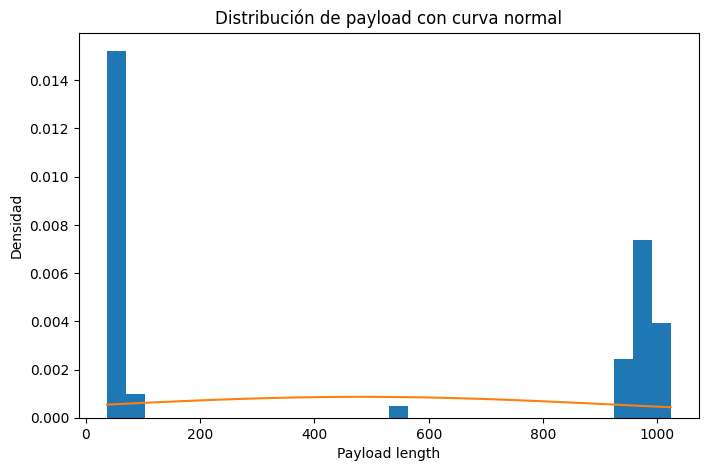

In [24]:
plt.figure(figsize=(8,5))

count, bins, _ = plt.hist(df["payload"], bins=30, density=True)

mean = df["payload"].mean()
std = df["payload"].std()

x = np.linspace(min(bins), max(bins), 100)
y = (1/(std * np.sqrt(2*np.pi))) * np.exp(-0.5*((x-mean)/std)**2)

plt.plot(x, y)

plt.title("Distribución de payload con curva normal")
plt.xlabel("Payload length")
plt.ylabel("Densidad")

plt.show()

Vemos que los valores no están centralizados, hay muchos datos que superan los 1000 bytes de tamaño mientras que otros rondan los 50 o 10. Por esa razón vamos a usar conocimiento experto. Una consulta DNS, en promedio,  tiene 50 bytes de tamaño y 15 bytes de desviación estándar

In [25]:
df["z_score_expert"] = (df["payload"] - 50) / 15

In [ ]:
df_new_anomalies = df[df['z_score_expert'] > 2]

In [27]:
print(df_new_anomalies.shape)

(30, 30)


In [31]:
df_new_anomalies['payload'].astype(int).describe()

count      30.000000
mean      935.600000
std       178.819616
min        89.000000
25%       959.500000
50%       978.000000
75%       990.500000
max      1023.000000
Name: payload, dtype: float64

In [69]:
df_new_anomalies['src'].value_counts()

src
10.1.10.53     29
75.75.75.75     1
Name: count, dtype: int64

In [70]:
df_new_anomalies['dst'].value_counts()

dst
84.54.22.33    29
10.1.10.53      1
Name: count, dtype: int64

In [71]:
df_new_anomalies['sport'].value_counts()

sport
53    30
Name: count, dtype: int64

In [72]:
df_new_anomalies['dport'].value_counts()

dport
53       29
23903     1
Name: count, dtype: int64

Las comunicaciones detectadas como anómalas con el z-score tienen estas características

- La IP de orígen es casi siempre la 10.1.10.53 y la de destino la 84.54.22.33
- Salen del puerto 53 desde la máquina de orígen y casi siempre se comunican con el puerto 53 de la máquina de destino, casi siempre usan el puerto de DNS
- El tamaño del payload de cada comunicación es mayor a 89 bytes 

Es importante conocer los protocolos ya que así, sabemos cuáles son los valores típicos o esperados en cierto tipo de conexión y de esa forma podemos ajustar de mejor manera los valores que vamos a usar para detectar anomalías. Un buen ejemplo de esto es el caso anterior, pues los datos originalmente no tenían una distribución normal y había conexiones con valores demasiado altos y otras con valores muy bajos, esto afectaba el valor de la media y la desviación estándar y no nos permitió identificar anomalías de forma correcta, sin embargo, gracias a que se sabe que la mayoría de conexiones del conjunto de datos es DNS y se tiene conocimiento del tamaño típico de este tipo de conexiones, realizamos un ajuste en los datos el cuál nos permitió detectar las anomalías de forma correcta. 

## Parte 2

In [40]:
def graph(group_col: str, interest_col: str, title: str, x_label: str, y_label: str):
    df.groupby(group_col)[interest_col].sum().plot(kind='barh', figsize=(10, 5))
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.tight_layout()
    plt.show()


1. Muestre una gráfica 2D, en el eje Y las IPs origen, y en el eje X la suma de los payloads enviados de dichas direcciones

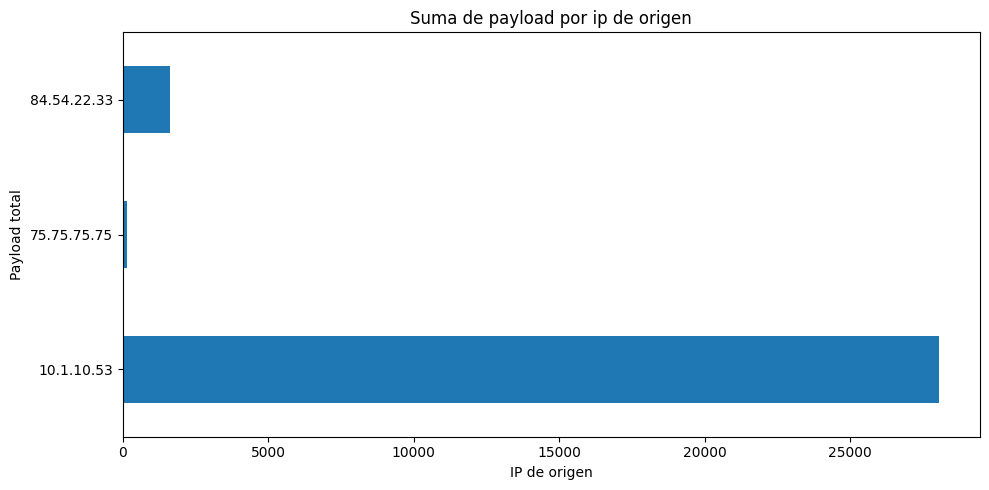

In [42]:
graph('src', 'payload', 'Suma de payload por ip de origen', 'IP de origen', 'Payload total')


2. Muestre una gráfica 2D, en el eje Y las IPs destino, y en el eje X la suma de los payloads recibidos en dichas direcciones.

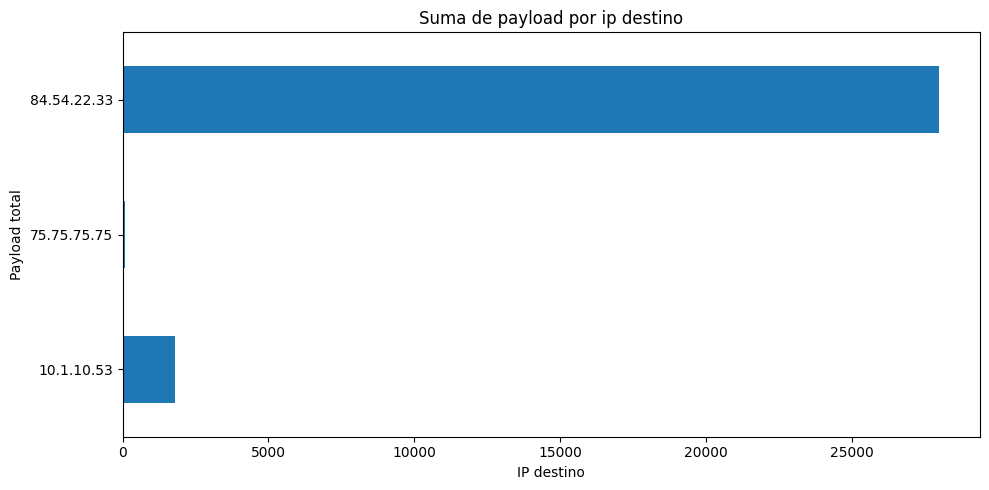

In [43]:
graph('dst', 'payload', 'Suma de payload por ip destino', 'IP destino', 'Payload total')

3. Muestre una gráfica 2D, en el eje Y los puertos origen, y en el eje X la suma de los payloads enviados de dichos puertos

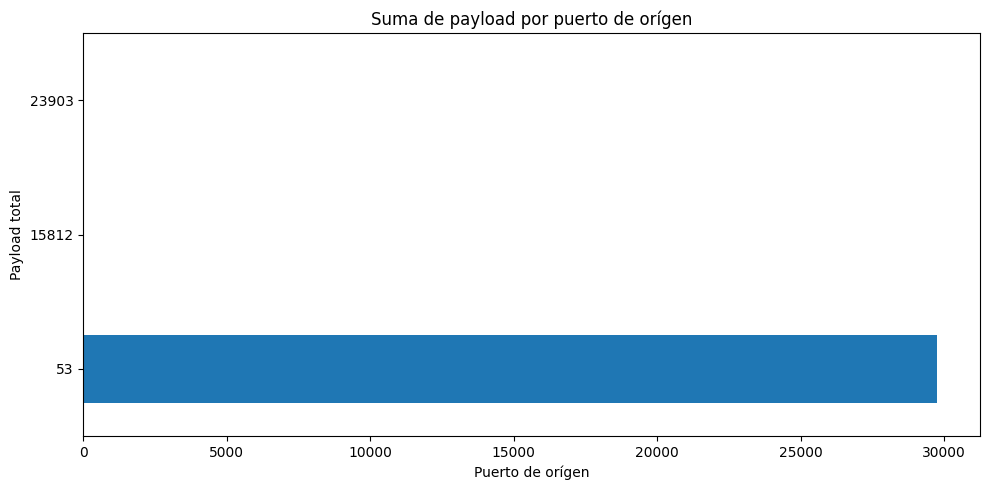

In [44]:
graph('sport', 'payload', 'Suma de payload por puerto de orígen', 'Puerto de orígen', 'Payload total')

4. Muestre una gráfica 2D, en el eje Y los puertos destino, y en el eje X la suma de los payloads recibidos en dichos puertos.

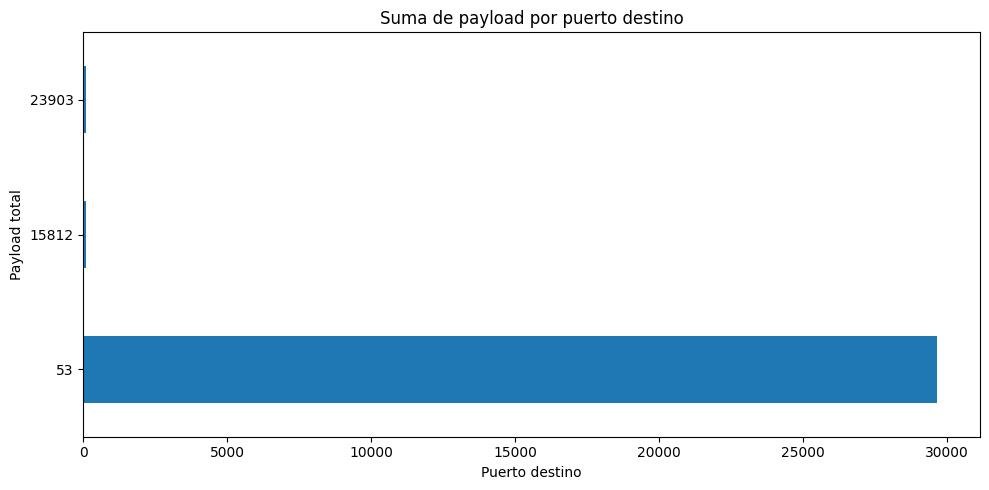

In [46]:
graph('dport', 'payload', 'Suma de payload por puerto destino', 'Puerto destino', 'Payload total')

## Parte 3

1. Utilice las columnas numéricas del DataFrame (payload_len y pkt_len) para entrenar un modelo de Isolation Forest con un valor igual al número de paquetes detectados en el inciso 4c dividido por el número de paquetes totales para definir su valor para el parámetro contamination. ¿Qué paquetes son marcados como anomalías?

Como detectamos 30 anomalías con el z-score y tenemos 62 observaciones, nuestro valor de contaminación será 0.5

In [48]:
features = df[['payload', 'len']]

In [51]:
iso_forest = IsolationForest(
    n_estimators=200,          
    contamination=30/62,      
    random_state=42,
    n_jobs=-1                  
)

iso_forest.fit(features)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",200
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.4838709677419355
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [53]:
# Get predictions: 1 = normal, -1 = anomaly
df['iso_pred'] = iso_forest.predict(features)

# Get anomaly scores (more negative = more anomalous)
df['iso_score'] = iso_forest.decision_function(features)

# Convert to a more intuitive scale: higher = more anomalous
df['iso_anomaly_score'] = -df['iso_score']

In [54]:
print('Isolation Forest trained (unsupervised — no labels used).\n')
print(f'Predictions:  {(df["iso_pred"]==-1).sum()} flagged as anomaly, '
      f'{(df["iso_pred"]==1).sum()} flagged as normal')
print(f'\nAnomaly score range: [{df["iso_anomaly_score"].min():.3f}, '
      f'{df["iso_anomaly_score"].max():.3f}]')

Isolation Forest trained (unsupervised — no labels used).

Predictions:  30 flagged as anomaly, 32 flagged as normal

Anomaly score range: [-0.013, 0.386]


Los datos entre -0.013 y 0 son normalesm mientras que los que están entre 0 y 0.386 son anómalos. Tenemos 32 datos normales y 30 anómalos, tal y como en el z-score. Vamos a verificar si se trata de los mismos puntos. 

In [56]:
df_new_anomalies.head()

,version,ihl,tos,len,id,flags,frag,ttl,proto,chksum,...,flags,window,chksum,urgptr,options,payload,payload_raw,payload_hex,z_score,z_score_expert
0,4,5,0,961,1,,0,64,17,21222,...,None,None,62990,None,None,933,b'\x00\x0c\x01\x00\x00\x01\x00\x00\x00\x00\x00...,b'000c0100000100000000000006676f6f676c6503636f...,0.981296,58.866667
2,4,5,0,975,1,,0,64,17,21208,...,None,None,36378,None,None,947,b'\x00\x0c\x01\x00\x00\x01\x00\x00\x00\x00\x00...,b'000c0100000100000000000006676f6f676c6503636f...,1.011713,59.8
4,4,5,0,1012,1,,0,64,17,21171,...,None,None,63846,None,None,984,b'\x00\x0c\x01\x00\x00\x01\x00\x00\x00\x00\x00...,b'000c0100000100000000000006676f6f676c6503636f...,1.092101,62.266667
6,4,5,0,998,1,,0,64,17,21185,...,None,None,65315,None,None,970,b'\x00\x0c\x01\x00\x00\x01\x00\x00\x00\x00\x00...,b'000c0100000100000000000006676f6f676c6503636f...,1.061684,61.333333
8,4,5,0,1003,1,,0,64,17,21180,...,None,None,38088,None,None,975,b'\x00\x0c\x01\x00\x00\x01\x00\x00\x00\x00\x00...,b'000c0100000100000000000006676f6f676c6503636f...,1.072547,61.666667


In [73]:
df_iso_anomalies = df[df['iso_anomaly_score'] > 0]

In [74]:
df_iso_anomalies['payload'].astype(int).describe()

count      30.000000
mean      842.833333
std       322.485614
min        37.000000
25%       942.500000
50%       976.000000
75%       990.500000
max      1023.000000
Name: payload, dtype: float64

In [75]:
df_iso_anomalies['src'].value_counts()

src
10.1.10.53     28
75.75.75.75     2
Name: count, dtype: int64

In [76]:
df_iso_anomalies['dst'].value_counts()

dst
84.54.22.33    26
75.75.75.75     2
10.1.10.53      2
Name: count, dtype: int64

In [77]:
df_iso_anomalies['sport'].value_counts()

sport
53       28
15812     1
23903     1
Name: count, dtype: int64

In [78]:
df_iso_anomalies['dport'].value_counts()

dport
53       28
15812     1
23903     1
Name: count, dtype: int64

El isolation forest detectó como anomalías algunas conexiones con un tamaño menor a 50, lo común en DNS a pesar de tener la misma cantidad de anomalías detectadas que el z-score. Vamos a ver que tantas conexiones tienen en común, para eso vamos a usar el tiempo como identificador único. 

In [68]:
iso_anom = set(df_iso_anomalies['time'].astype(float).unique())
z_anom = set(df_new_anomalies['time'].astype(float).unique())

common = iso_anom.intersection(z_anom)

print(len(common))

27


En total, la evaluación de anomalías con z-score y isolation forest tienen 27 observaciones de 30 en total en común.  La IP de destino más frecuente en ambos enfoques es la 10.1.10.53 y la de destino es 84.54.22.33, casi siempre usan el puerto asignado para DNS, en cuánto al tamaño del payload, el z-score consideró como anómalas sola aquellas conexiones que superaban los 89 bytes de tamaño, mientras que el isolation forest consideró como anomalías las que estaban por encima de los 37 bytes, esto discrepa un poco con el valor promedio de una conexión DNS, el cuál es de 50 bytes. En general, las anomalías obtenidas usando cada uno de los enfoques coincide bastante. 

## Parte 4

1. Cree un nuevo DataFrame que incluya únicamente las conexiones con la dirección IP orígen más frecuente.

In [79]:
df_frequent_src_ip = df[df['src'] == '10.1.10.53']

2. Obtenga un nuevo DataFrame con las columnas Src Address, Dst Address y agrúpelas
por payload.

In [85]:

df_grouped = df_frequent_src_ip[['src', 'dst', 'payload']].groupby(['src', 'dst'])['payload'].sum()

3. Obtenga la IP que más ha intercambiado bytes con la IP más frecuente. Confirme que esta es la misma IP sospechosa identificada por las técnicas automáticas.

In [86]:
print(df_grouped)

src         dst        
10.1.10.53  75.75.75.75       74
            84.54.22.33    27979
Name: payload, dtype: object


La IP con la que más intercambia bytes la ip de orígen más frecuentes es la 84.54.22.33, esto coincide con la mayoría de observaciones que han sido catalogadas como anómalas por el z-score y el isolation forest. 

4. Cree un nuevo DataFrame con la conversación entre la IP más frecuente y la IP sospechosa.

In [92]:
df_conversation = df[
    ((df['src'] == '10.1.10.53') & (df['dst'] == '84.54.22.33')) |
    ((df['src'] == '84.54.22.33') & (df['dst'] == '10.1.10.53'))
]

In [93]:
payloads = df_conversation['payload_raw'].tolist()

In [96]:
print(payloads[0].decode('utf-8', errors='ignore'))

         googlecom   �PNG

IHDR  b      (�TR  :�IDATx��	|T�����;K�
�����iaK����u}Ųw�d���"`:����&�9Ɛ� ��1ҌQHP*�@O4���7<y�.9���a2@a��&"��c�kO�s@�9�i�4X�x�K�a!f��0w��3dx"���C(�}�0|q�*���a!f�4��.�sKg]=9NԂ��u���K_�e*���Px��%���3��"E?���+H�]Q�k����8�"�4v�2���咯̸|�x.\�-b�I�B���@�L��CJ]XWQ����uQ�kQ�N�1 ���2�03�\�@!�H�BJqG'+�R�U\[����GXC;��Ԏ�q�!�r�s=�rԴ���_S�%�ph�aY����c���P�9�


Vemos que se está enviando un archivo PNG, esto no debe enviarse mediante DNS pues solamente se realizan consultas sobre la IP de un dominio. Podría catalogarse como un ataque de infección ya que, mediante la infiltración al sistema mediante el puerto DNS el atacante puede estar introduciendo código malicioso en nuestro sistema.

Es importante combinar las técnicas automáticas y la investigación manual ya que, las herramientas automáticas nos pueden ayudar a identificar de mejor forma cuál es el tráfico en el que debemos centrar nuestro análisis, sin embargo, siempre se debe verificar manualmente si el output de dichas herramientas es correcto o tiene sentido, verficar manualmente también nos ayuda a identificar que es exactamente lo que el atacante está haciendo y así poder prepararnos mejor para defendernos de forma correcta. 